In [13]:
import os
import neurovoc
import tempfile
import librosa

import numpy as np
import matplotlib.pyplot as plt
import scipy
from IPython.display import Audio

import utils_demo as utils

In [14]:
n_fft = 512
hops = 32

n_mels = 64
min_freq = 150
max_freq = 10_500
mel_scale = librosa.filters.mel_frequencies(n_mels, fmin=min_freq, fmax=max_freq)

root = "../data"

### Simple Spectrogram

(64, 1983)


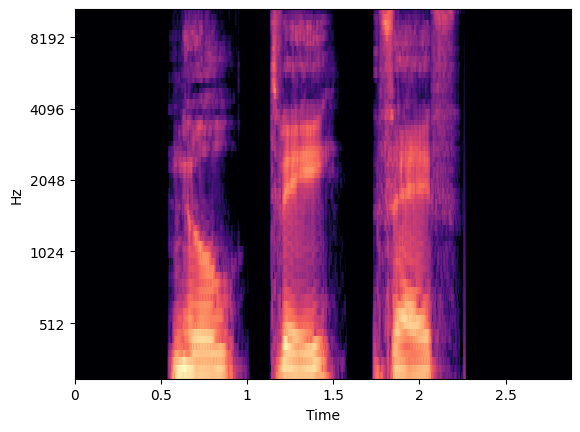

In [15]:
soundname_025 = "din/triplets/025.wav"
filename_025 = os.path.join(root, soundname_025)
y, sr = librosa.load(filename_025)


S_db = utils.get_melspectrogram(y, sr, n_fft, hops)
print(S_db.shape)
librosa.display.specshow(S_db, x_axis='time',
                         y_axis='mel', sr=sr,
                          fmin=min_freq, fmax=max_freq, 
                         n_fft=n_fft, hop_length=hops)

## Run Neurovoc Encoder with Specres

### Original Spectrogram vs Neurogram

In [16]:
def create_specres_neurogram(soundfile):
    filename = os.path.join(root, soundfile)
    y, sr = librosa.load(filename)
    S_db = utils.get_melspectrogram(y, sr, n_fft, hops)

    neurogram = neurovoc.specres(filename, n_trials=1)
    
    utils.plot_spectro_vs_neurogram(S_db, y, neurogram, sr, hops, soundfile)  
    
    return neurogram

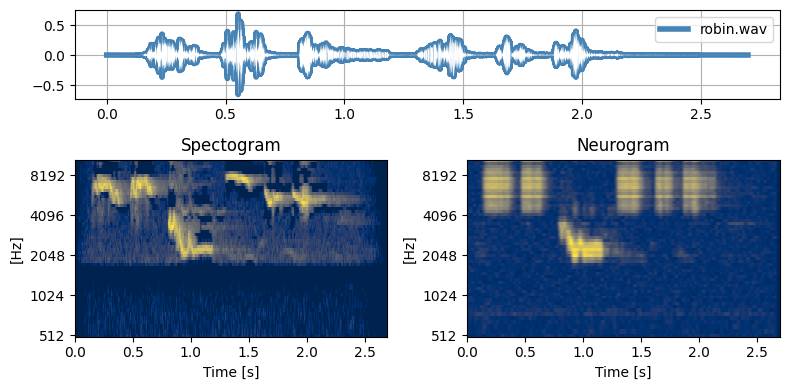

In [17]:
soundname_robin = "robin.wav"
neurogram_robin = create_specres_neurogram(soundname_robin)

The frequency alignment of the model is appropriate, due to the ‘learned‘
frequencies. 

Lower temporal precision due to CIS, which requires that all electrode pairs be stimulated
for a single cycle of the strategy

Moreover, since there is only one electrode pair that stimulates signals over 4 248 Hz (see Table 2 in the Appendix),
there is very little precision for high-frequency stimuli

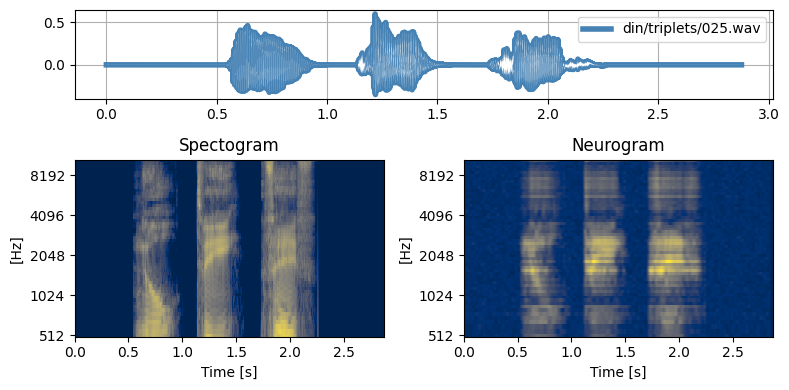

In [18]:
neurogram_025 = create_specres_neurogram(soundname_025)

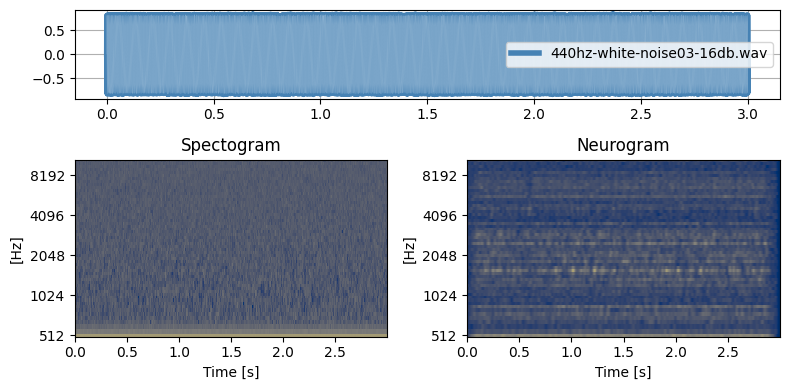

In [25]:
soundname_noise_16 = "440hz-white-noise03-16db.wav"
neurogram_noise_16 = create_specres_neurogram(soundname_noise_16)

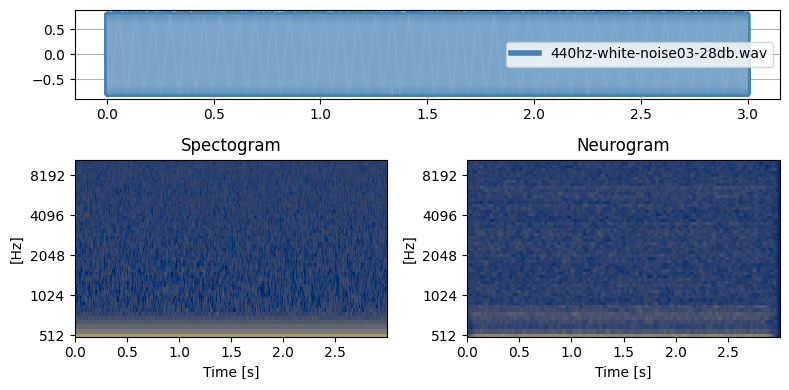

In [28]:
soundname_noise_28 = "440hz-white-noise03-28db.wav"
neurogram_noise_28 = create_specres_neurogram(soundname_noise_28)

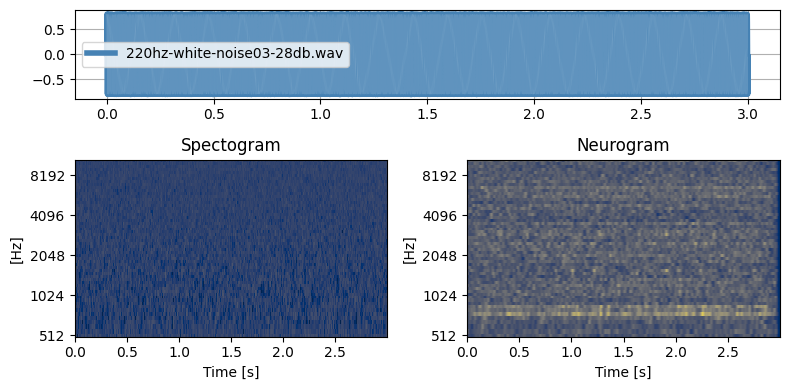

In [30]:
soundname_noise_220hz_28 = "220hz-white-noise03-28db.wav"
neurogram_noise_220hz_28 = create_specres_neurogram(soundname_noise_220hz_28)

## Reconstruct

In [20]:
def reconstruct(neurogram, soundfile):
    reconstructed = neurovoc.reconstruct(neurogram)
    
    filename = os.path.join(root, soundfile)
    original, fs = librosa.load(filename, sr=None)
    reconstructed = scipy.signal.resample(reconstructed, original.size)

    neurovoc.audio_vs_reconstructed(
        original,
        reconstructed,
        fs,
        len(neurogram.frequencies),
        neurogram.min_freq, 
        neurogram.max_freq, 
    )
    
    plt.show()
    
    utils.plot_and_play_reconstructed(original, reconstructed, fs, mel_scale, soundfile)
    return reconstructed

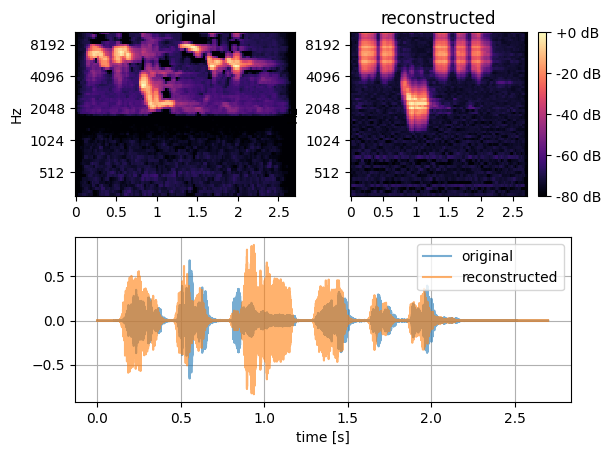

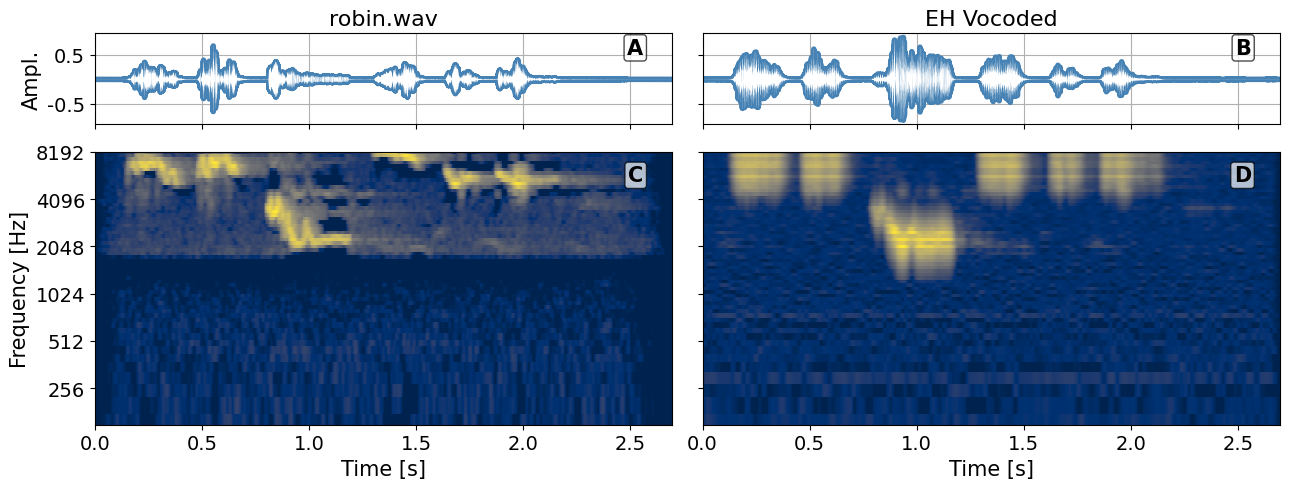

In [21]:
reconstructed_robin = reconstruct(neurogram_robin, soundname_robin)

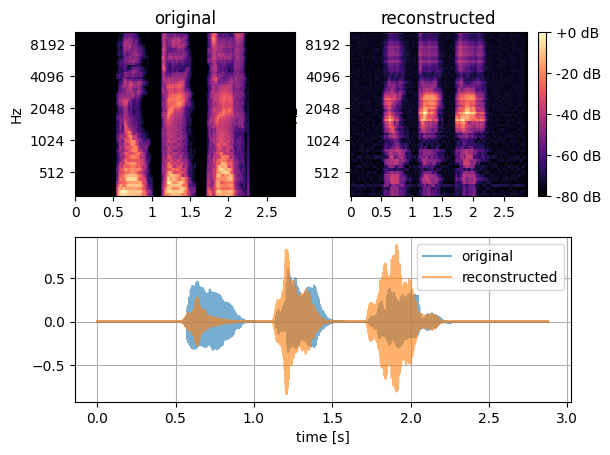

array([-3.9357852e-04, -4.0109409e-04, -2.7664844e-05, ...,
        3.6708111e-04,  4.1534068e-04,  1.3090391e-04],
      shape=(126885,), dtype=float32)

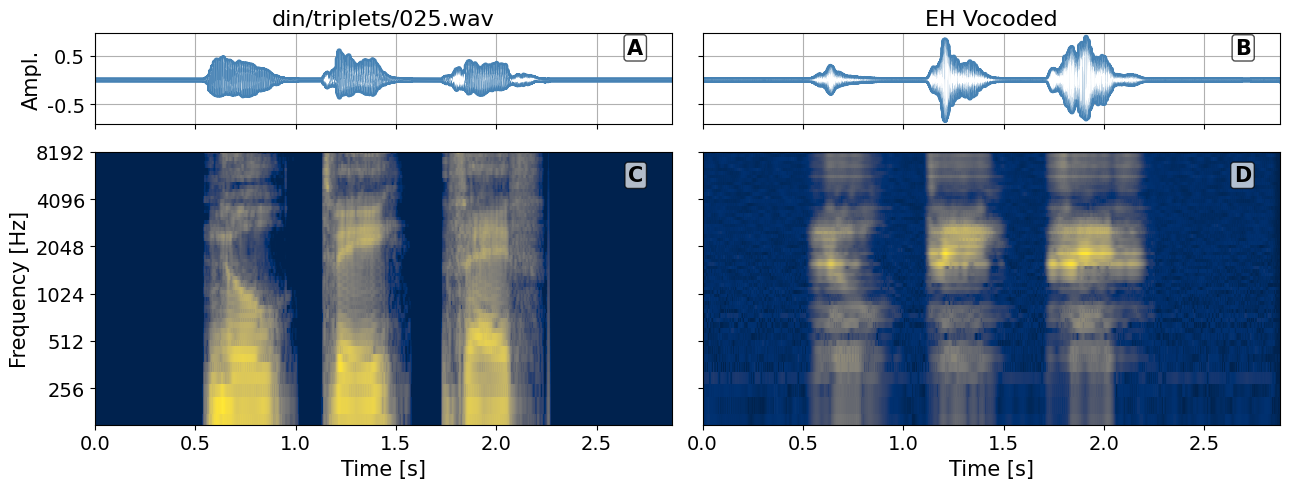

In [24]:
reconstruct(neurogram_025, soundname_025)

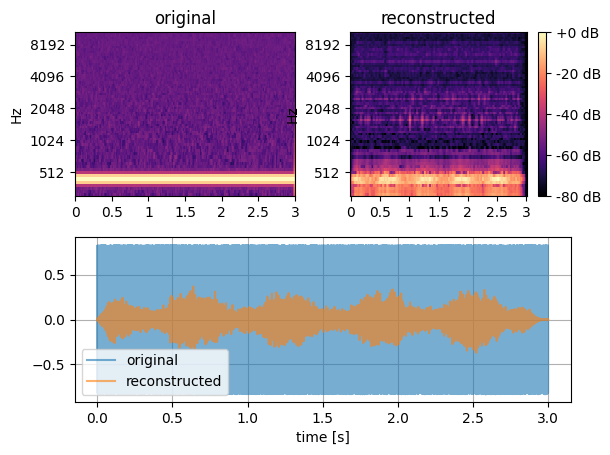

array([-4.9497252e-03, -7.7825165e-03, -7.4193357e-03, ...,
       -2.7429374e-05,  4.1741958e-05, -1.9929847e-07],
      shape=(132300,), dtype=float32)

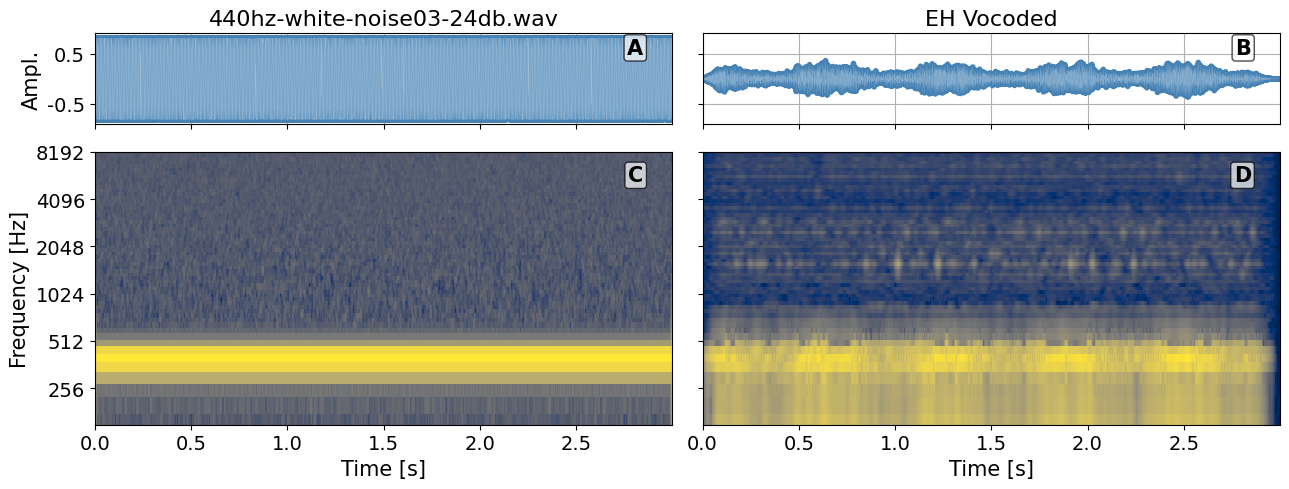

In [ ]:
reconstruct(neurogram_noise_16, soundname_noise_16)

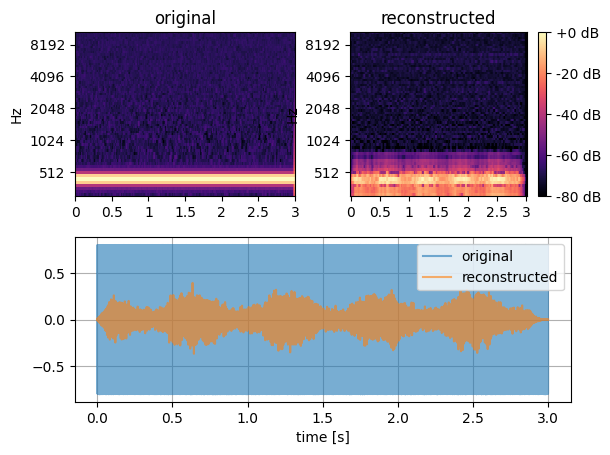

array([ 5.9162858e-03,  8.2055274e-03,  8.4704105e-03, ...,
       -1.2374221e-04, -6.3581749e-05,  2.5558182e-07],
      shape=(132300,), dtype=float32)

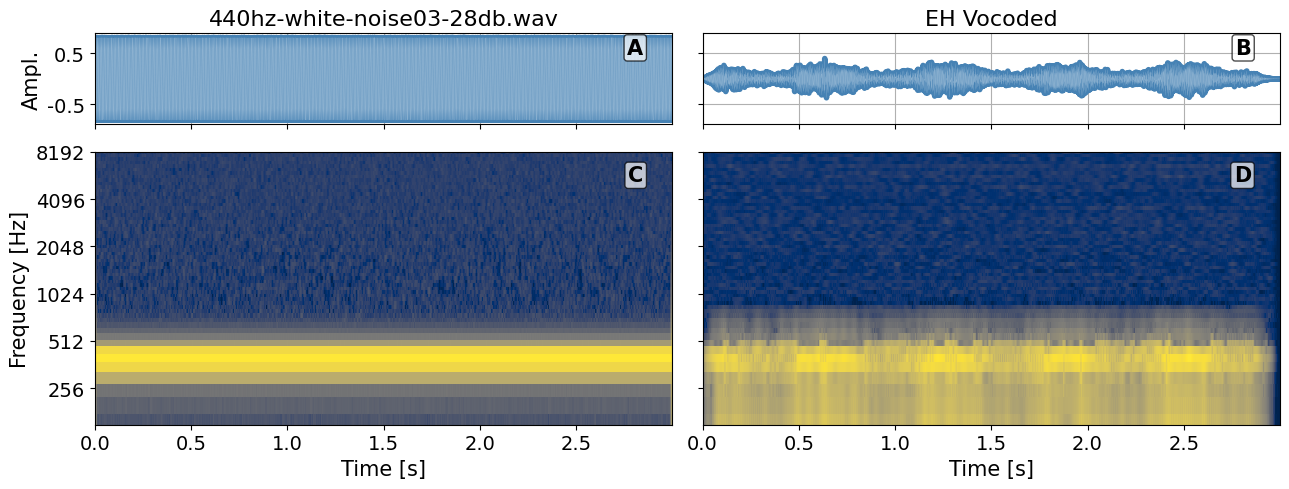

In [29]:
reconstruct(neurogram_noise_28, soundname_noise_28)

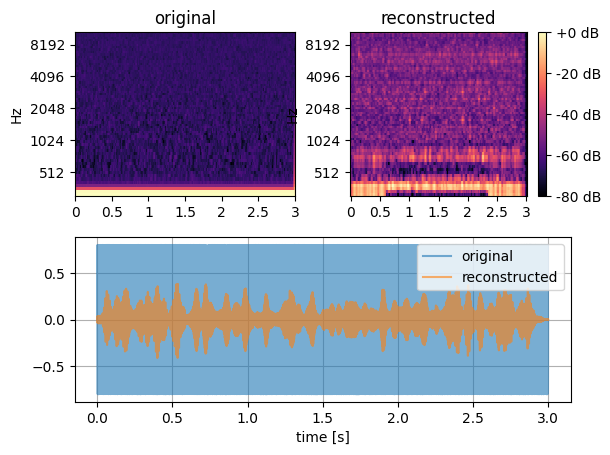

array([2.1182081e-02, 2.9319717e-02, 2.8295759e-02, ..., 6.5901360e-05,
       8.7174623e-05, 7.8981247e-07], shape=(132300,), dtype=float32)

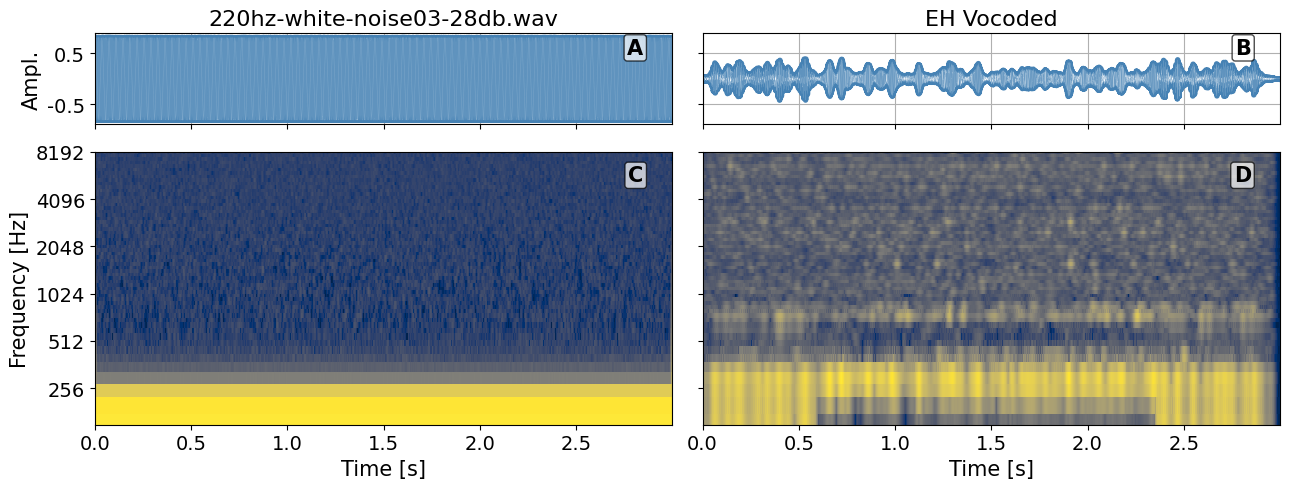

In [31]:
reconstruct(neurogram_noise_220hz_28, soundname_noise_220hz_28)